#Task 1 clean code


In [4]:
!pip install datasets transformers sacrebleu rouge_score nltk torch sentencepiece evaluate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 5.5 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=03555473367df63553e1f1ee2ddecc9a63befab177a8badd013fa0efd1dbcf0d
  Stored in directory: /root/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge_score


In [5]:
# Uninstall the previous installed nltk library
!pip install -U nltk

# This upgraded nltkto version 3.5 in which meteor_score is there.
!pip install nltk==3.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.9 MB/s eta 0:00:0000:01
  Attempting uninstall: nltk
    Found existing installation: nltk 3.2.4
    Uninstalling nltk-3.2.4:
      Successfully uninstalled nltk-3.2.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
preprocessing 0.1.13 requires nltk==3.2.4, but you have nltk 3.9.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.3 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
  Created wheel for nltk: filename=nltk-3.5-py3-none-any.whl size=1434674 sha256=d1c955dd03456bba57d54dfc53685b99667a595e50d76c1b18cd129b35e00fc1
  Stored in directory: /root/.cache/pip/wheels/35/ab/82/f9667f6f884d272670a15382599a9c753a1dfdc83f7412e37d
Successfully built nltk
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
     

In [6]:
import os
import torch
import nltk
import sacrebleu
import evaluate
from datasets import load_dataset
from rouge_score import rouge_scorer
from transformers import MarianTokenizer, MarianMTModel, DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments
from torch.utils.data import DataLoader
from nltk.translate.meteor_score import meteor_score
import numpy as np


os.environ["WANDB_DISABLED"] = "true"

nltk.download("punkt")
nltk.download("wordnet")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [7]:
# Load full dataset
dataset = load_dataset("cfilt/iitb-english-hindi")
train_data = dataset["train"]
val_data = dataset["validation"]
test_data = dataset["test"]
print(dataset)

# New parameter: percentage of data to use for fine tuning
data_percentage = 10  # use 10% of the data

# Subset the train and validation datasets
def subset_dataset(ds, percentage):
    total = len(ds)
    num_examples = int(total * (percentage / 100))
    return ds.select(range(num_examples))

train_data = subset_dataset(train_data, data_percentage)
print(len(train_data))
#val_data = subset_dataset(val_data, data_percentage)

README.md:   0%|          | 0.00/3.14k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/190M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/85.7k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/500k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1659083 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/520 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2507 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 1659083
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 520
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 2507
    })
})
165908


In [8]:
# Initialize tokenizer and model (original model for fine-tuning)
model_name = "Helsinki-NLP/opus-mt-en-hi"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/812k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


pytorch_model.bin:   0%|          | 0.00/306M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

In [9]:
# Preprocessing function
def preprocess_function(batch):
    source_texts = [ex["en"] for ex in batch["translation"]]
    target_texts = [ex["hi"] for ex in batch["translation"]]
    model_inputs = tokenizer(source_texts, truncation=True, padding="max_length", max_length=128)
    labels = tokenizer(target_texts, truncation=True, padding="max_length", max_length=128)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [10]:
# Tokenize full training and validation datasets
tokenized_train = train_data.map(preprocess_function, batched=True)
tokenized_train.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_val = val_data.map(preprocess_function, batched=True)

Map:   0%|          | 0/165908 [00:00<?, ? examples/s]

Map:   0%|          | 0/520 [00:00<?, ? examples/s]

Fine Tuning - Part 1 of the Assignment

In [11]:
# Set up Data Collator and DataLoader
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)
train_dataloader = DataLoader(tokenized_train, batch_size=8, shuffle=True, collate_fn=data_collator)

In [12]:
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")

def compute_metrics(pred):
    predictions, references = pred
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_refs = tokenizer.batch_decode(references, skip_special_tokens=True)

    # Compute BLEU score
    bleu_score = bleu_metric.compute(predictions=decoded_preds, references=[[ref] for ref in decoded_refs])["bleu"]

    # Compute ROUGE scores
    rouge_scores = rouge_metric.compute(predictions=decoded_preds, references=decoded_refs)
    print(rouge_scores)
    rouge1 = np.mean(rouge_scores["rouge1"])
    rouge2= np.mean(rouge_scores["rouge2"])
    rougeL = np.mean(rouge_scores["rougeL"])


    # Compute METEOR score
    from nltk.translate.meteor_score import meteor_score
    meteor_scores = [meteor_score([ref], pred) for pred, ref in zip(decoded_preds, decoded_refs)]
    meteor_avg = sum(meteor_scores) / len(meteor_scores)

    return {
        "BLEU": bleu_score,
        "ROUGE-1": rouge1,
        "ROUGE-2": rouge2,
        "ROUGE-L": rougeL,
        "METEOR": meteor_avg,
    }

In [13]:
# Training arguments for full dataset fine-tuning
"""training_args = Seq2SeqTrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=5,
    predict_with_generate=True
)"""
"""
training_args = Seq2SeqTrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",  # Align with eval strategy
    load_best_model_at_end=True,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    learning_rate=2e-5,
    weight_decay=0.01,
    predict_with_generate=True
)

training_args = Seq2SeqTrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    learning_rate=5e-5,
    weight_decay=0.05,
    predict_with_generate=True,
    fp16=True,
    logging_dir="./logs",
    logging_strategy="epoch",
    report_to=["tensorboard"]
)

training_args = Seq2SeqTrainingArguments(
        output_dir="./results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=4,            # Increased epochs for more gradual learning
        learning_rate=3e-5,            # Lower learning rate for more stable updates
        weight_decay=0.1,              # Slightly increased weight decay to help reduce overfitting
        warmup_steps=1000,             # Added warmup steps for a gradual ramp-up of learning rate
        predict_with_generate=True,
        fp16=True,
        logging_dir="./logs",
        logging_strategy="epoch",
        report_to=["tensorboard"],
        label_smoothing_factor=0.1     # Added label smoothing to help reduce overconfidence and overfitting
    )
    
training_args = Seq2SeqTrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,  # Effective batch size = 16
    num_train_epochs=3,  # Stick to 3 epochs  
    learning_rate=2e-5,  # Slightly increased for faster convergence
    weight_decay=0.1,
    warmup_steps=500,  # Reduced warmup to start learning earlier  
    predict_with_generate=True,
    fp16=True,
    logging_dir="./logs",
    logging_strategy="epoch",
    report_to=["tensorboard"],
    label_smoothing_factor=0.05  # Reduced to prevent over-regularization  
)


training_args = Seq2SeqTrainingArguments(
    output_dir="./results_alt",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    per_device_train_batch_size=16,  # Larger batch for better generalization
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=1,  # No accumulation since batch is larger
    num_train_epochs=4,  # One extra epoch to see long-term trends
    learning_rate=3e-5,  # Slightly higher LR for faster adaptation
    weight_decay=0.05,  # Slightly lower to prevent underfitting
    warmup_ratio=0.06,  # Dynamic warmup (6% of total steps)
    predict_with_generate=True,
    fp16=True,
    logging_dir="./logs_alt",
    logging_strategy="epoch",
    report_to=["tensorboard"],
    label_smoothing_factor=0.1,  # Higher smoothing to prevent overconfidence
)
"""

training_args = Seq2SeqTrainingArguments(
    output_dir="./results_mod_batch",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,  # Effective batch size = 16
    num_train_epochs=4,             # Capped at 4 epochs
    learning_rate=2.5e-5,           # Moderated LR for stable convergence
    weight_decay=0.1,               # Same as previous moderate config
    warmup_ratio=0.05,              # Ratio-based warmup
    predict_with_generate=True,
    fp16=True,
    logging_dir="./logs_mod_batch",
    logging_strategy="epoch",
    report_to=["tensorboard"],
    label_smoothing_factor=0.07,    # Balanced smoothing
)


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [14]:
# Initialize trainer with full train and validation datasets
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

<ipython-input-14-e8410114582a>:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [15]:
# Fine-tune model
trainer.train()

# Save the fine-tuned model and tokenizer
model.save_pretrained("fine_tuned_opus-mt-en-hi")
tokenizer.save_pretrained("fine_tuned_opus-mt-en-hi")

/usr/local/lib/python3.10/dist-packages/transformers/data/data_collator.py:657: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


Epoch,Training Loss,Validation Loss,Bleu,Rouge-1,Rouge-2,Rouge-l,Meteor
1,1.386100,2.383038,0.009948,0.046644,0.005577,0.045110,0.101956
2,1.109200,2.355511,0.014367,0.051815,0.008013,0.050055,0.104266
3,1.074700,2.343016,0.012809,0.050718,0.008269,0.049636,0.103307


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Tr

{'rouge1': 0.0466437728937729, 'rouge2': 0.0055769230769230765, 'rougeL': 0.04510989010989011, 'rougeLsum': 0.04552197802197802}


/usr/local/lib/python3.10/dist-packages/transformers/modeling_utils.py:2817: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[61949]]}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now

...

{'rouge1': 0.05891712454212455, 'rouge2': 0.010256410256410256, 'rougeL': 0.057946428571428565, 'rougeLsum': 0.05834020146520147}


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Tr

{'rouge1': 0.050718240093240094, 'rouge2': 0.008269230769230768, 'rougeL': 0.04963640526140526, 'rougeLsum': 0.050486180486180476}


There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.encoder.embed_positions.weight', 'model.decoder.embed_tokens.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].


('fine_tuned_opus-mt-en-hi/tokenizer_config.json',
 'fine_tuned_opus-mt-en-hi/special_tokens_map.json',
 'fine_tuned_opus-mt-en-hi/vocab.json',
 'fine_tuned_opus-mt-en-hi/source.spm',
 'fine_tuned_opus-mt-en-hi/target.spm',
 'fine_tuned_opus-mt-en-hi/added_tokens.json')

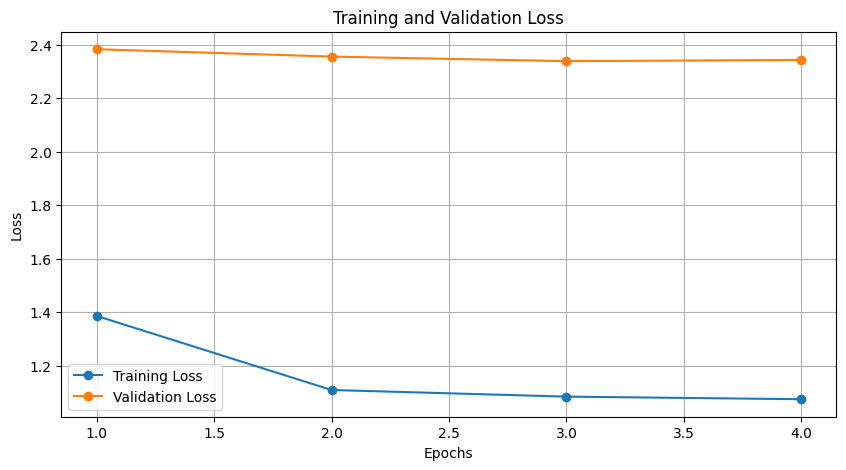

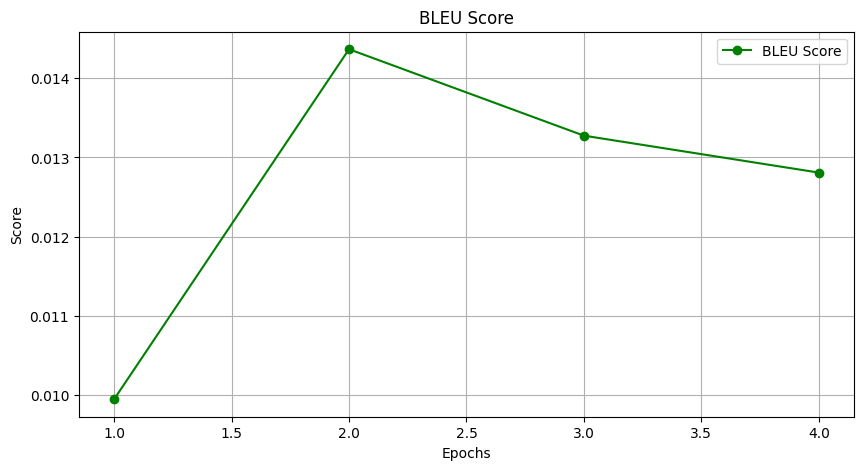

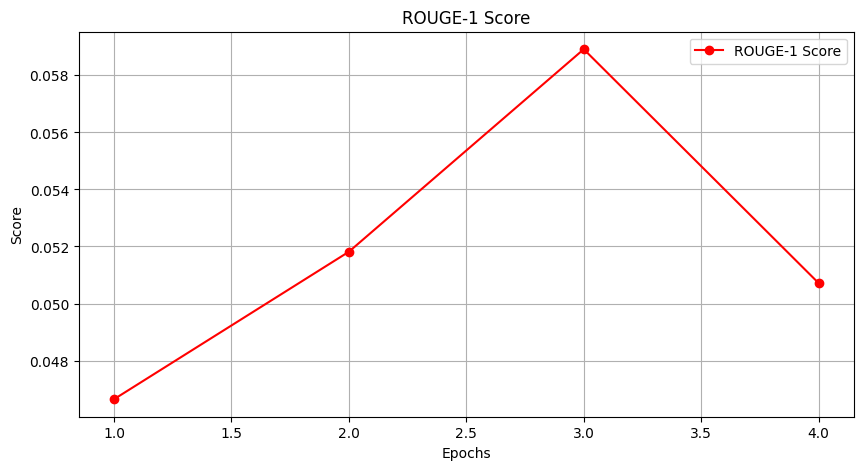

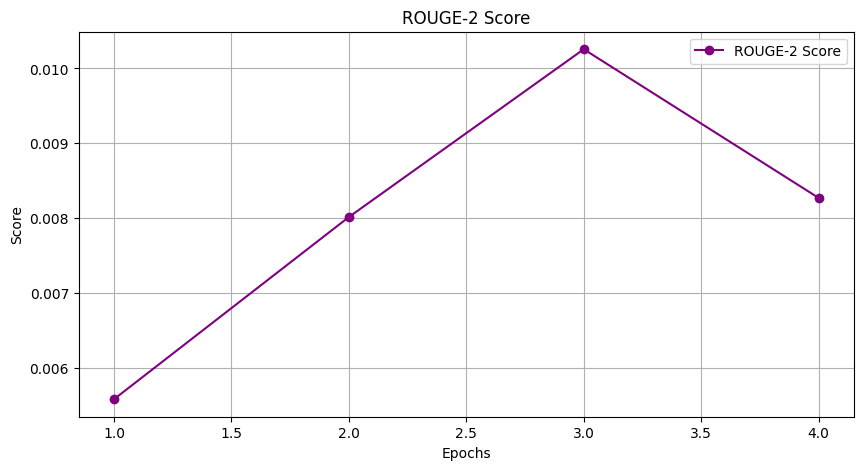

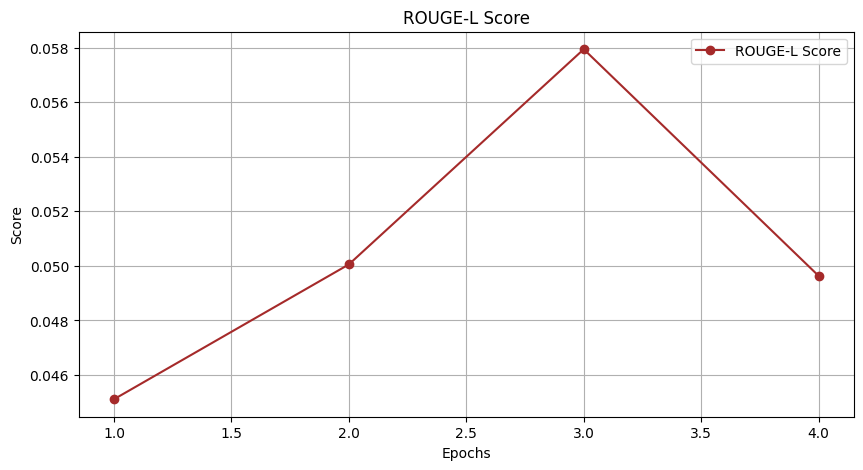

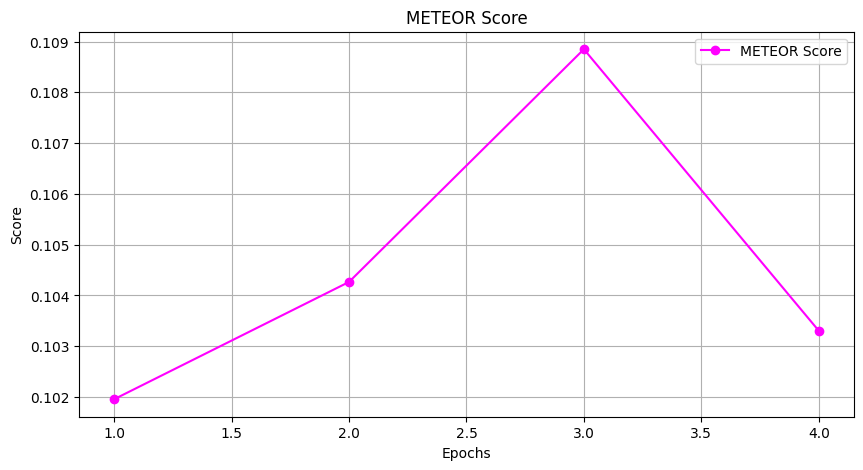

In [28]:
import json
import matplotlib.pyplot as plt

# Load training log
log_file_path = "./results_mod_batch/checkpoint-" + "41476/" + "trainer_state.json"  # Path to trainer state log
with open(log_file_path, "r") as f:
    logs = json.load(f)["log_history"]

# Aggregate logs by epoch (using the first entry per epoch)
data = {}
for log in logs:
    if "epoch" in log:
        epoch = log["epoch"]
        # Only add if we haven't seen this epoch
        if epoch not in data:
            data[epoch] = {}
        # Save metrics if they exist
        for key in ["loss", "eval_loss", "eval_BLEU", "eval_ROUGE-1", "eval_ROUGE-2", "eval_ROUGE-L", "eval_METEOR"]:
            if key in log:
                data[epoch][key] = log[key]

# Sort epochs
epochs = sorted(data.keys())

# Create lists for each metric
train_loss = [data[ep].get("loss", None) for ep in epochs]
val_loss   = [data[ep].get("eval_loss", None) for ep in epochs]
bleu_scores = [data[ep].get("eval_BLEU", None) for ep in epochs]
rouge1_scores = [data[ep].get("eval_ROUGE-1", None) for ep in epochs]
rouge2_scores = [data[ep].get("eval_ROUGE-2", None) for ep in epochs]
rougeL_scores = [data[ep].get("eval_ROUGE-L", None) for ep in epochs]
meteor_scores = [data[ep].get("eval_METEOR", None) for ep in epochs]

# Helper function: Filter out epochs and corresponding metric values that are None
def filter_data(x, y):
    x_filtered = [xi for xi, yi in zip(x, y) if yi is not None]
    y_filtered = [yi for yi in y if yi is not None]
    return x_filtered, y_filtered

# Filter data for each metric
epochs_train, train_loss = filter_data(epochs, train_loss)
epochs_val, val_loss = filter_data(epochs, val_loss)
epochs_bleu, bleu_scores = filter_data(epochs, bleu_scores)
epochs_rouge1, rouge1_scores = filter_data(epochs, rouge1_scores)
epochs_rouge2, rouge2_scores = filter_data(epochs, rouge2_scores)
epochs_rougeL, rougeL_scores = filter_data(epochs, rougeL_scores)
epochs_meteor, meteor_scores = filter_data(epochs, meteor_scores)

# Plot Loss Curves on a single graph using two y-axes if needed
plt.figure(figsize=(10, 5))
plt.plot(epochs_train, train_loss, label="Training Loss", marker="o")
plt.plot(epochs_val, val_loss, label="Validation Loss", marker="o")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot BLEU Score
plt.figure(figsize=(10, 5))
plt.plot(epochs_bleu, bleu_scores, label="BLEU Score", marker="o", color='green')
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.title("BLEU Score")
plt.legend()
plt.grid(True)
plt.show()

# Plot ROUGE-1 Score
plt.figure(figsize=(10, 5))
plt.plot(epochs_rouge1, rouge1_scores, label="ROUGE-1 Score", marker="o", color='red')
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.title("ROUGE-1 Score")
plt.legend()
plt.grid(True)
plt.show()

# Plot ROUGE-2 Score
plt.figure(figsize=(10, 5))
plt.plot(epochs_rouge2, rouge2_scores, label="ROUGE-2 Score", marker="o", color='purple')
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.title("ROUGE-2 Score")
plt.legend()
plt.grid(True)
plt.show()

# Plot ROUGE-L Score
plt.figure(figsize=(10, 5))
plt.plot(epochs_rougeL, rougeL_scores, label="ROUGE-L Score", marker="o", color='brown')
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.title("ROUGE-L Score")
plt.legend()
plt.grid(True)
plt.show()

# Plot METEOR Score
plt.figure(figsize=(10, 5))
plt.plot(epochs_meteor, meteor_scores, label="METEOR Score", marker="o", color='magenta')
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.title("METEOR Score")
plt.legend()
plt.grid(True)
plt.show()


Evaluation of the Fine Tuned Model

In [16]:
# Reload fine-tuned model and tokenizer
model = MarianMTModel.from_pretrained("fine_tuned_opus-mt-en-hi")
tokenizer = MarianTokenizer.from_pretrained("fine_tuned_opus-mt-en-hi")

/usr/local/lib/python3.10/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

MarianMTModel(
  (model): MarianModel(
    (shared): Embedding(61950, 512, padding_idx=61949)
    (encoder): MarianEncoder(
      (embed_tokens): Embedding(61950, 512, padding_idx=61949)
      (embed_positions): MarianSinusoidalPositionalEmbedding(512, 512)
      (layers): ModuleList(
        (0-5): 6 x MarianEncoderLayer(
          (self_attn): MarianAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation_fn): SiLU()
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (final_layer_norm): LayerNorm((512,), eps=1e-05

In [18]:
# Load evaluation metrics
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")

In [19]:
def evaluate_model(test_data, num_samples=None):
    predictions, references = [], []
    # Use full test dataset if num_samples is None
    num_samples = len(test_data) if num_samples is None else num_samples
    print(num_samples)
    for i, example in enumerate(test_data):
        print(i)
        if i >= num_samples:
            break
        source_text = example["translation"]["en"]
        reference_text = example["translation"]["hi"]
        inputs = tokenizer(source_text, return_tensors="pt", truncation=True, padding=True).to(device)
        with torch.no_grad():
            outputs = model.generate(**inputs, max_length=128)
        generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        predictions.append(generated_text)
        references.append([reference_text])
    return predictions, references

In [20]:
def ensure_string(text):
    # If text is a list, join it into a string; otherwise, return as is.
    return " ".join(text) if isinstance(text, list) else text

def compute_metrics(decoded_preds, decoded_refs):

    # For BLEU, references should be a list of lists of strings.
    bleu_score = bleu_metric.compute(
        predictions=decoded_preds, 
        references=[[ensure_string(ref)] for ref in decoded_refs]
    )["bleu"]
    
    # Compute ROUGE scores, ensuring references are strings.
    rouge_scores = rouge_metric.compute(
        predictions=decoded_preds, 
        references=[ensure_string(ref) for ref in decoded_refs]
    )
    print(rouge_scores)
    rouge1 = np.mean(rouge_scores["rouge1"])
    rouge2 = np.mean(rouge_scores["rouge2"])
    rougeL = np.mean(rouge_scores["rougeL"])

    # Compute METEOR score, ensuring both references and predictions are strings.
    from nltk.translate.meteor_score import meteor_score
    meteor_scores = [
        meteor_score([ensure_string(ref)], ensure_string(pred))
        for pred, ref in zip(decoded_preds, decoded_refs)
    ]
    meteor_avg = sum(meteor_scores) / len(meteor_scores)

    return {
        "BLEU": bleu_score,
        "ROUGE-1": rouge1,
        "ROUGE-2": rouge2,
        "ROUGE-L": rougeL,
        "METEOR": meteor_avg,
    }

In [21]:
# Evaluate on full test dataset


preds, refs = evaluate_model(test_data)  # full dataset

metrics = compute_metrics(preds, refs)
print("Evaluation Metrics (Fine-Tuned Model):", metrics)

2507
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
2

In [57]:
metrics = compute_metrics(preds, refs)
print("Evaluation Metrics (Fine-Tuned Model):", metrics)

{'rouge1': 0.046, 'rouge2': 0.024, 'rougeL': 0.045111111111111116, 'rougeLsum': 0.04484444444444445}
Evaluation Metrics (Fine-Tuned Model): {'BLEU': 0.01001764000751081, 'ROUGE-1': 0.046, 'ROUGE-2': 0.024, 'ROUGE-L': 0.045111111111111116, 'METEOR': 0.08186523205776067}


In [22]:
ls

fine_tuned_opus-mt-en-hi/  logs_mod_batch/  results_mod_batch/


In [23]:
cd results_mod_batch

/kaggle/working/results_mod_batch


In [24]:
ls

checkpoint-10370/  checkpoint-20740/  checkpoint-31110/  checkpoint-41476/


In [26]:
cd ..

/kaggle/working


In [29]:
!zip -r fine_tuned_opus-mt-en-hi.zip fine_tuned_opus-mt-en-hi


  adding: fine_tuned_opus-mt-en-hi/ (stored 0%)
  adding: fine_tuned_opus-mt-en-hi/tokenizer_config.json (deflated 68%)
  adding: fine_tuned_opus-mt-en-hi/special_tokens_map.json (deflated 35%)
  adding: fine_tuned_opus-mt-en-hi/vocab.json (deflated 76%)
  adding: fine_tuned_opus-mt-en-hi/model.safetensors (deflated 7%)
  adding: fine_tuned_opus-mt-en-hi/source.spm (deflated 51%)
  adding: fine_tuned_opus-mt-en-hi/generation_config.json (deflated 43%)
  adding: fine_tuned_opus-mt-en-hi/target.spm (deflated 60%)
  adding: fine_tuned_opus-mt-en-hi/config.json (deflated 61%)


In [30]:
!ls -la


total 276216
drwxr-xr-x 6 root root      4096 Apr  1 22:41 .
drwxr-xr-x 5 root root      4096 Apr  1 19:04 ..
drwxr-xr-x 2 root root      4096 Apr  1 22:02 fine_tuned_opus-mt-en-hi
-rw-r--r-- 1 root root 282818769 Apr  1 22:41 fine_tuned_opus-mt-en-hi.zip
drwxr-xr-x 2 root root      4096 Apr  1 19:06 logs_mod_batch
drwxr-xr-x 6 root root      4096 Apr  1 21:59 results_mod_batch
drwxr-xr-x 2 root root      4096 Apr  1 19:04 .virtual_documents


In [31]:
from IPython.display import FileLink
FileLink('fine_tuned_opus-mt-en-hi.zip')


/kaggle/working/fine_tuned_opus-mt-en-hi.zip